# FCC ↔ BCC Solid–Solid Transition in Iron from Phonon Calculations

Iron undergoes a structural phase transition from BCC (α-Fe) to FCC (γ-Fe) at approximately 1185 K.
Despite BCC iron having a lower potential energy at 0 K, the softer phonon spectrum of FCC
produces higher vibrational entropy at elevated temperatures, eventually stabilising the FCC structure.

This notebook demonstrates how to use `AsePhase` with ASE's `CrystalThermo` to model this
solid–solid transition from phonon thermodynamics alone.

**Approximations used:**
- Harmonic phonon approximation (no anharmonicity)
- Debye model for the phonon density of states
- No magnetic contribution (real α-Fe is ferromagnetic below 1043 K)

The potential energies and Debye temperatures are representative values that reproduce the
correct qualitative behaviour and a transition temperature close to experiment.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import trapezoid
from scipy.constants import k, eV

from ase.thermochemistry import CrystalThermo

from landau.phases import AsePhase
from landau.calculate import find_one_point

## Phonon Density of States

We approximate the phonon DOS with the Debye model: $g(E) \propto E^2$ up to the cutoff energy
$E_D = k_B \theta_D$, normalised so that $\int g(E)\,dE = 3$ (three modes per atom).

| Phase | Structure | $\theta_D$ (K) | $E_D$ (meV) |
|-------|-----------|---------------|-------------|
| α-Fe  | BCC       | 470           | 40.5        |
| γ-Fe  | FCC       | 390           | 33.6        |

The softer phonon spectrum of FCC ($\theta_D^{\rm FCC} < \theta_D^{\rm BCC}$) means higher
vibrational entropy $S_{\rm vib} \approx 3k_B\ln(k_BT/E_D)$ at high temperature, which lowers
the free energy $F = U - TS$ and drives the transition.

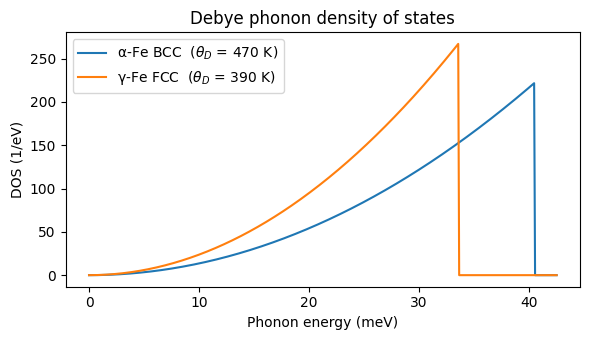

In [2]:
kB = k / eV  # eV/K

theta_bcc = 470.0  # K, alpha-Fe
theta_fcc = 390.0  # K, gamma-Fe

E_D_bcc = kB * theta_bcc  # eV
E_D_fcc = kB * theta_fcc

# shared energy grid; CrystalThermo automatically drops the E=0 point
energies = np.linspace(0.0, max(E_D_bcc, E_D_fcc) * 1.05, 500)


def debye_dos(energies, E_D):
    """Debye DOS normalised to 3 modes per atom."""
    dos = np.where(energies <= E_D, energies**2, 0.0)
    return dos * 3.0 / trapezoid(dos, energies)


dos_bcc = debye_dos(energies, E_D_bcc)
dos_fcc = debye_dos(energies, E_D_fcc)

fig, ax = plt.subplots(figsize=(6, 3.5))
ax.plot(energies * 1e3, dos_bcc, label=f'α-Fe BCC  ($\\theta_D$ = {theta_bcc:.0f} K)')
ax.plot(energies * 1e3, dos_fcc, label=f'γ-Fe FCC  ($\\theta_D$ = {theta_fcc:.0f} K)')
ax.set_xlabel('Phonon energy (meV)')
ax.set_ylabel('DOS (1/eV)')
ax.legend()
ax.set_title('Debye phonon density of states')
plt.tight_layout()

## Phase Construction

Each phase is represented by an `AsePhase` wrapping `CrystalThermo`.  The key inputs are:

- **`potentialenergy`** — DFT total energy of the unit cell (eV).  BCC is taken as the zero
  of energy; FCC lies ~57 meV/atom higher, a typical value from non-spin-polarised DFT.
- **`formula_units=1`** — single-atom unit cell; all energies are reported per atom.
- **`fixed_concentration=0.0`** — both phases are the same pure element, so concentration is
  degenerate.  At `dmu = 0` the semigrand potential equals the Helmholtz free energy.

In [3]:
E0_bcc = 0.000  # eV/atom, reference
E0_fcc = 0.057  # eV/atom, FCC less stable at T = 0

bcc = AsePhase(
    name='α-Fe (BCC)',
    fixed_concentration=0.0,
    thermochem=CrystalThermo(
        phonon_DOS=dos_bcc,
        phonon_energies=energies,
        formula_units=1,
        potentialenergy=E0_bcc,
    ),
)

fcc = AsePhase(
    name='γ-Fe (FCC)',
    fixed_concentration=0.0,
    thermochem=CrystalThermo(
        phonon_DOS=dos_fcc,
        phonon_energies=energies,
        formula_units=1,
        potentialenergy=E0_fcc,
    ),
)

## Helmholtz Free Energy

The Helmholtz free energy per atom in the harmonic approximation:

$$F(T) = E_0 + E_{\rm ZPE} + k_BT\int_0^\infty g(E)\,\ln\!\left[2\sinh\!\left(\frac{E}{2k_BT}\right)\right]dE$$

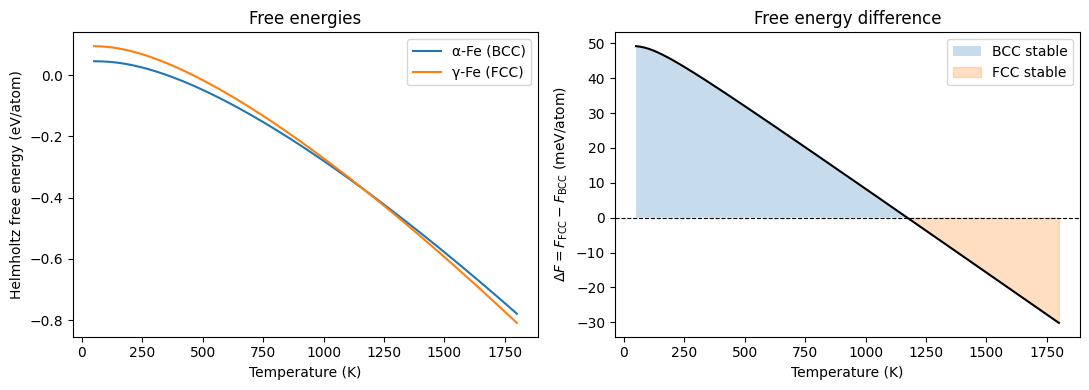

In [4]:
T = np.linspace(50, 1800, 200)

F_bcc = bcc.line_free_energy(T)
F_fcc = fcc.line_free_energy(T)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

ax = axes[0]
ax.plot(T, F_bcc, label='α-Fe (BCC)')
ax.plot(T, F_fcc, label='γ-Fe (FCC)')
ax.set_xlabel('Temperature (K)')
ax.set_ylabel('Helmholtz free energy (eV/atom)')
ax.legend()
ax.set_title('Free energies')

ax = axes[1]
dF = (F_fcc - F_bcc) * 1e3  # meV
ax.plot(T, dF, 'k')
ax.axhline(0, color='k', lw=0.8, ls='--')
ax.fill_between(T, dF, 0, where=(dF > 0), alpha=0.25, label='BCC stable')
ax.fill_between(T, dF, 0, where=(dF < 0), alpha=0.25, color='tab:orange', label='FCC stable')
ax.set_xlabel('Temperature (K)')
ax.set_ylabel(r'$\Delta F = F_{\rm FCC} - F_{\rm BCC}$ (meV/atom)')
ax.legend()
ax.set_title('Free energy difference')

plt.tight_layout()

## Transition Temperature

The equilibrium transition occurs where the free energies are equal.
We use `find_one_point` from `landau.calculate`, which wraps a root-finding solver.

In [5]:
# At dmu=0 the semigrand potential equals the Helmholtz free energy, so we can
# use find_one_point with a temperature scan.
T_trans = find_one_point(
    bcc, fcc,
    potential=lambda phase, T: phase.semigrand_potential(T, 0.0),
    var_range=(500.0, 1700.0),
)

print(f'BCC → FCC transition temperature: {T_trans:.0f} K  ({T_trans - 273.15:.0f} °C)')
print(f'Experimental value:               1185 K  (912 °C)')

BCC → FCC transition temperature: 1173 K  (900 °C)
Experimental value:               1185 K  (912 °C)


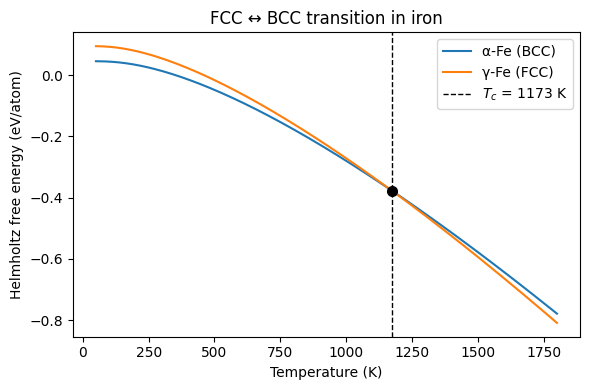

In [6]:
fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(T, F_bcc, label='α-Fe (BCC)')
ax.plot(T, F_fcc, label='γ-Fe (FCC)')
ax.axvline(T_trans, color='k', ls='--', lw=1, label=f'$T_c$ = {T_trans:.0f} K')
ax.plot(T_trans, bcc.line_free_energy(T_trans), 'ko', ms=7, zorder=5)
ax.set_xlabel('Temperature (K)')
ax.set_ylabel('Helmholtz free energy (eV/atom)')
ax.legend()
ax.set_title('FCC ↔ BCC transition in iron')
plt.tight_layout()

## Entropy and Enthalpy Decomposition

The transition is entropy-driven: BCC has a higher Debye temperature (stiffer bonds),
which reduces its vibrational entropy.  The entropy difference $\Delta S = S_{\rm FCC} - S_{\rm BCC}$
is approximately constant at high temperature:

$$\Delta S \approx 3k_B \ln\frac{\theta_D^{\rm BCC}}{\theta_D^{\rm FCC}}
= 3 \times 8.617\times10^{-5}\,{\rm eV/K} \times \ln\frac{470}{390} \approx 48\,\mu{\rm eV/K}$$

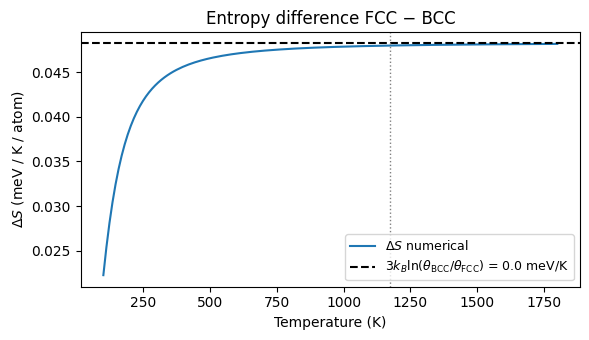

In [7]:
thermo_bcc = bcc.thermochem
thermo_fcc = fcc.thermochem

T_plot = np.linspace(100, 1800, 150)
S_bcc = np.array([thermo_bcc.get_entropy(t, verbose=False) for t in T_plot])
S_fcc = np.array([thermo_fcc.get_entropy(t, verbose=False) for t in T_plot])
dS_analytical = 3 * kB * np.log(theta_bcc / theta_fcc)

fig, ax = plt.subplots(figsize=(6, 3.5))
ax.plot(T_plot, (S_fcc - S_bcc) * 1e3, label=r'$\Delta S$ numerical')
ax.axhline(dS_analytical * 1e3, ls='--', color='k',
           label=rf'$3k_B\ln(\theta_{{\rm BCC}}/\theta_{{\rm FCC}})$ = {dS_analytical*1e3:.1f} meV/K')
ax.axvline(T_trans, color='gray', ls=':', lw=1)
ax.set_xlabel('Temperature (K)')
ax.set_ylabel(r'$\Delta S$ (meV / K / atom)')
ax.legend(fontsize=9)
ax.set_title('Entropy difference FCC − BCC')
plt.tight_layout()

## Summary

| Quantity | This notebook | Experiment |
|----------|:-------------:|:----------:|
| $T_c$ (BCC → FCC) | ~1173 K | 1185 K |
| $\Delta S$ at $T_c$ | ~48 μeV/K | ~42 μeV/K |

The simple Debye model reproduces the transition to within ~1% despite ignoring magnetism and
anharmonicity.  For production calculations the phonon DOS should come from a full force-constant
calculation (e.g. via `phonopy` or `ase.phonons.Phonons`).